In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from darts import TimeSeries
from darts.models import TransformerModel
from darts.dataprocessing.transformers import Scaler
from darts.metrics import mae, rmse, r2_score


/data/ll2531/venv/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
with open("processed_data_pkl/imputed_training_data.pkl", "rb") as f:
    traffic_dic = pickle.load(f)

with open("processed_data_pkl/weather_global_2014_2025.pkl", "rb") as f:
    weather = pickle.load(f)

air_qual = pd.read_csv("online_data/air_qual/air_qual.csv")

air_qual.drop(columns=["aerosol_optical_depth ()", "dust (μg/m³)"], errors="ignore", inplace=True)
air_qual.dropna(inplace=True)
air_qual.reset_index(inplace=True, drop=True)

air_qual["time"] = pd.to_datetime(air_qual["time"], errors="coerce")
weather["timestamp"] = pd.to_datetime(weather["timestamp"], errors="coerce")

weather = weather[weather["timestamp"].isin(air_qual["time"])]
weather.reset_index(inplace=True, drop=True)

dataset = pd.merge(weather, air_qual, left_on="timestamp", right_on="time", how="inner")


In [3]:
# --- 2. Clock-Anchored Feature Engineering ---
dataset["hour_sin"] = dataset["timestamp"].apply(lambda x: np.sin(2 * np.pi * x.hour / 24.0))
dataset["hour_cos"] = dataset["timestamp"].apply(lambda x: np.cos(2 * np.pi * x.hour / 24.0))

FEATURE_COLS = ["pm2_5 (μg/m³)", "hour_sin", "hour_cos"]
TARGET_COL = "pm2_5 (μg/m³)"

df = dataset[FEATURE_COLS + ["timestamp"]].copy()
df.set_index("timestamp", inplace=True)
df = df.sort_index().asfreq("h") 

# --- 3. Darts TimeSeries Extraction ---
all_features_series = TimeSeries.from_dataframe(df, value_cols=FEATURE_COLS)
target_series = TimeSeries.from_dataframe(df, value_cols=[TARGET_COL])
covariates_series = TimeSeries.from_dataframe(df, value_cols=["hour_sin", "hour_cos"])

# --- 4. Chronological Splitting ---
SPLIT_DATE = pd.Timestamp("2025-01-01 00:00:00")
TEST_END_DATE = pd.Timestamp("2025-01-31 23:00:00")

train_target, val_target = target_series.split_before(SPLIT_DATE)
train_cov, val_cov = covariates_series.split_before(SPLIT_DATE)

val_target = val_target.slice(SPLIT_DATE, TEST_END_DATE)
val_cov = val_cov.slice(SPLIT_DATE, TEST_END_DATE)

In [4]:
# --- 5. Data Normalization (Scikit-Learn Wrapper) ---
target_scaler = Scaler(MinMaxScaler())
cov_scaler = Scaler(MinMaxScaler())

train_target_scaled = target_scaler.fit_transform(train_target)
val_target_scaled = target_scaler.transform(val_target)

train_cov_scaled = cov_scaler.fit_transform(train_cov)
val_cov_scaled = cov_scaler.transform(val_cov)

In [5]:
import optuna
import logging
from darts.models import TransformerModel
from sklearn.metrics import mean_squared_error


INPUT_WINDOW = 24 * 3
OUTPUT_WINDOW = 24
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if DEVICE == "cuda":
    torch.set_float32_matmul_precision("high")
# 1. Disable Optuna logs spamming the console (Optional)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 2. Define the Objective Function for Optuna
def objective(trial):
    # --- Define Hyperparameter Search Space ---
    # Categorical and integer hyperparameter suggestions
    d_model = trial.suggest_categorical("d_model", [32, 64, 128])
    nhead = trial.suggest_categorical("nhead", [4, 8])
    num_layers = trial.suggest_int("num_encoder_layers", 1, 4)
    dim_feedforward = trial.suggest_categorical("dim_feedforward", [64, 128, 256])
    dropout = trial.suggest_float("dropout", 0.1, 0.4)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    
    N_EPOCHS_TUNING = 30 

    # --- Instantiate the Model with Trial Suggestions ---
    trial_model = TransformerModel(
        input_chunk_length=INPUT_WINDOW,
        output_chunk_length=OUTPUT_WINDOW,
        d_model=d_model,
        nhead=nhead,
        num_encoder_layers=num_layers,
        num_decoder_layers=num_layers,
        dim_feedforward=dim_feedforward,
        dropout=dropout,
        activation="relu",
        batch_size=batch_size,
        n_epochs=N_EPOCHS_TUNING,
        optimizer_kwargs={"lr": lr, "weight_decay": weight_decay},
        pl_trainer_kwargs={
            "accelerator": DEVICE, 
            "devices": 1, 
            "enable_checkpointing": False
        },
    )

    # --- Train the Model ---
    trial_model.fit(
        series=train_target_scaled, 
        past_covariates=train_cov_scaled, 
        val_series=val_target_scaled, 
        val_past_covariates=val_cov_scaled,
        verbose=False
    )


    scaled_forecasts_trial = trial_model.historical_forecasts(
        series=val_target_scaled,
        past_covariates=val_cov_scaled,
        start=INPUT_WINDOW,
        forecast_horizon=OUTPUT_WINDOW,
        stride=12,
        retrain=False,
        last_points_only=False,
        verbose=False
    )

    true_forecasts_trial = [target_scaler.inverse_transform(f) for f in scaled_forecasts_trial]
    true_targets_trial = [val_target.slice_intersect(f) for f in true_forecasts_trial]

    all_pred_vals = np.concatenate([f.univariate_values() for f in true_forecasts_trial])
    all_true_vals = np.concatenate([t.univariate_values() for t in true_targets_trial])

    trial_rmse = np.sqrt(mean_squared_error(all_true_vals, all_pred_vals))
    
    return trial_rmse

print("Starting Bayesian Optimization Study...")
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler())
study.optimize(objective, n_trials=20)

print("\n--- Optimization Finished ---")
print("Best Trial Value (RMSE):", study.best_trial.value)
print("Best Hyperparameters found:")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")

/data/ll2531/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data/ll2531/venv/lib/python3.10/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)
/data/ll2531/venv/lib/python3.10/site-packages/torch/random.py:187: UserWarning: CUDA reports t

Starting Bayesian Optimization Study...


Authorization required, but no authorization protocol specified
Authorization required, but no authorization protocol specified
hwloc/linux: Ignoring PCI device with non-16bit domain.
Pass --enable-32bits-pci-domain to configure to support such devices
(warning: it would break the library ABI, don't enable unless really needed).
Authorization required, but no authorization protocol specified
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
`Trainer.fit` stopped: `max_epochs=30` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/ll2531/venv/lib/python3.10/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first f


--- Optimization Finished ---
Best Trial Value (RMSE): 4.016511547140421
Best Hyperparameters found:
  d_model: 64
  nhead: 4
  num_encoder_layers: 4
  dim_feedforward: 256
  dropout: 0.1252734967836691
  batch_size: 128
  lr: 0.0006225260594756446
  weight_decay: 3.350300538266804e-06


In [6]:
from pytorch_lightning.callbacks import Callback

class SimpleLossTracker(Callback):
    def __init__(self):
        self.train_losses = []
        self.val_losses = []

    def on_train_epoch_end(self, trainer, pl_module):
        train_loss = trainer.callback_metrics.get("train_loss")
        if train_loss is not None:
            self.train_losses.append(train_loss.item())

    def on_validation_epoch_end(self, trainer, pl_module):
        val_loss = trainer.callback_metrics.get("val_loss")
        if val_loss is not None:
            self.val_losses.append(val_loss.item())

loss_tracker = SimpleLossTracker()

In [7]:
best_params = study.best_trial.params

# Instantiate final model with optimized parameters
final_model = TransformerModel(
    input_chunk_length=INPUT_WINDOW,
    output_chunk_length=OUTPUT_WINDOW,
    d_model=best_params["d_model"],
    nhead=best_params["nhead"],
    num_encoder_layers=best_params["num_encoder_layers"],
    num_decoder_layers=best_params["num_encoder_layers"],
    dim_feedforward=best_params["dim_feedforward"],
    dropout=best_params["dropout"],
    activation="relu",
    batch_size=best_params["batch_size"],
    n_epochs=20, # Full training run
    optimizer_kwargs={"lr": best_params["lr"], "weight_decay": best_params["weight_decay"]},
    pl_trainer_kwargs={"accelerator": DEVICE, "devices": 1, "callbacks": [loss_tracker]},
)

# Fit and execute your remaining original metrics/Plotly plotting blocks!
final_model.fit(series=train_target_scaled, past_covariates=train_cov_scaled, val_series=val_target_scaled, val_past_covariates=val_cov_scaled)

/data/ll2531/venv/lib/python3.10/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name                | Type                | Params | Mode 
--------------------------------------------------------------------
0 | criterion           | MSELoss             | 0      | train
1 | train_criterion     | MSELoss             | 0      | train
2 | val_criterion       | MSELoss             | 0      | train
3 | train_metrics       | MetricCollection    | 0      | train
4 | val_metrics         | MetricCollection    | 0      | train
5 | encoder             | Linear              | 256    | train
6 | positional_encoding | _PositionalEncod

Epoch 19: 100%|██████████| 616/616 [00:20<00:00, 30.63it/s, train_loss=0.00309, val_loss=0.00298]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 616/616 [00:20<00:00, 30.63it/s, train_loss=0.00309, val_loss=0.00298]


TransformerModel(output_chunk_shift=0, d_model=64, nhead=4, num_encoder_layers=4, num_decoder_layers=4, dim_feedforward=256, dropout=0.1252734967836691, activation=relu, norm_type=None, custom_encoder=None, custom_decoder=None, input_chunk_length=72, output_chunk_length=24, batch_size=128, n_epochs=20, optimizer_kwargs={'lr': 0.0006225260594756446, 'weight_decay': 3.350300538266804e-06}, pl_trainer_kwargs={'accelerator': 'cuda', 'devices': 1, 'callbacks': [<__main__.SimpleLossTracker object at 0x7f2e84fb5660>]})

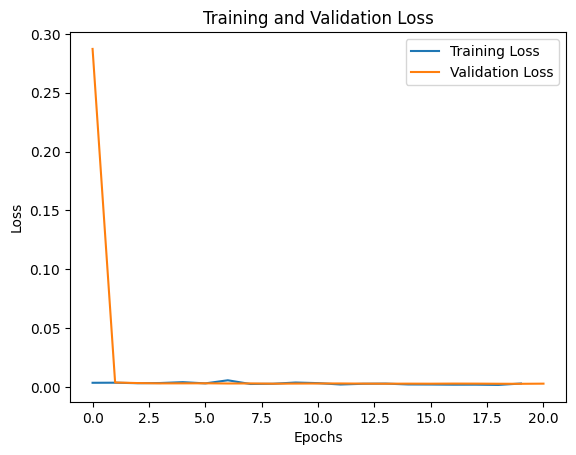

Generating rolling predictions (1-hour stride)...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Global R² Score     : 0.5980
Global MAE          : 2.8512 μg/m³
Global RMSE         : 4.0877 μg/m³
MAE% (Normalized)   : 0.31
RMSE% (Normalized)  : 0.44


In [8]:
plt.plot(loss_tracker.train_losses, label='Training Loss')
plt.plot(loss_tracker.val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.show()
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score as sklearn_r2

print("Generating rolling predictions (1-hour stride)...")
scaled_forecasts = final_model.historical_forecasts(
    series=val_target_scaled,
    past_covariates=val_cov_scaled,
    start=INPUT_WINDOW,
    forecast_horizon=OUTPUT_WINDOW,
    stride=1,
    retrain=False,
    last_points_only=False
)

true_forecasts = [target_scaler.inverse_transform(f) for f in scaled_forecasts]
true_targets = [val_target.slice_intersect(f) for f in true_forecasts]

all_pred_values = np.concatenate([f.univariate_values() for f in true_forecasts])
all_true_values = np.concatenate([t.univariate_values() for t in true_targets])

# --- 4. Global Metrics Calculation ---
global_mae = mean_absolute_error(all_true_values, all_pred_values)
global_rmse = np.sqrt(mean_squared_error(all_true_values, all_pred_values))
global_r2 = sklearn_r2(all_true_values, all_pred_values)

baseline_mean = np.mean(all_true_values)
mae_percentage = (global_mae / baseline_mean)
rmse_percentage = (global_rmse / baseline_mean)

print(f"Global R² Score     : {global_r2:.4f}")
print(f"Global MAE          : {global_mae:.4f} μg/m³")
print(f"Global RMSE         : {global_rmse:.4f} μg/m³")
print(f"MAE% (Normalized)   : {mae_percentage:.2f}")
print(f"RMSE% (Normalized)  : {rmse_percentage:.2f}")

import plotly.graph_objects as go

sample_indices = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600]
num_samples = len(sample_indices)

fig_darts = go.Figure()
buttons_darts = []

for idx, sample_idx in enumerate(sample_indices):
    # FIXED: Extract the single TimeSeries chunk directly from the list instead of sub-slicing
    target_chunk = true_targets[sample_idx]
    forecast_chunk = true_forecasts[sample_idx]
    
    # Extract univariate numpy arrays out of the single TimeSeries object
    true_actual_darts = target_chunk.univariate_values()
    true_pred_darts = forecast_chunk.univariate_values()
    
    # Extract the timestamps from the chunk
    window_timestamps_darts = target_chunk.time_index
    time_labels_darts = [str(t).split()[1][:5] for t in window_timestamps_darts]
    date_str_darts = str(window_timestamps_darts[0]).split()[0]
    
    fig_darts.add_trace(go.Scatter(
        x=time_labels_darts, y=true_actual_darts, mode='lines+markers',
        name=f'Actual PM2.5 ({date_str_darts})', line=dict(color='seagreen', width=3),
        visible=(idx == 0)
    ))
    fig_darts.add_trace(go.Scatter(
        x=time_labels_darts, y=true_pred_darts, mode='lines+markers',
        name=f'Darts Transformer Forecast ({date_str_darts})', line=dict(color='darkorange', width=2, dash='dash'),
        visible=(idx == 0)
    ))
    
    visibility_mask_darts = [False] * (num_samples * 2)
    visibility_mask_darts[idx * 2] = True
    visibility_mask_darts[idx * 2 + 1] = True
    
    buttons_darts.append(dict(
        label=f"Horizon: {date_str_darts}", method="update",
        args=[{"visible": visibility_mask_darts}, {"title": f"<b>Darts Transformer Performance Horizon: {date_str_darts}</b>"}]
    ))

# FIXED: Extract the date string safely from the first time series element in the list
initial_date_darts = str(true_targets[0].time_index[0]).split()[0]

fig_darts.update_layout(
    title=dict(text=f'<b>Darts Transformer Performance Horizon: {initial_date_darts}</b>', x=0.5, font=dict(size=16)),
    updatemenus=[dict(buttons=buttons_darts, direction="down", pad={"r": 10, "t": 10}, showactive=True, x=0.0, xanchor="left", y=1.15, yanchor="top")],
    xaxis=dict(title='Hour of Day (24h Forecast Horizon)', showgrid=True, gridcolor='lightgray'),
    yaxis=dict(title='PM2.5 Concentration (μg/m³)', showgrid=True, gridcolor='lightgray'),
    template='plotly_white', hovermode='x unified', height=550, width=900,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig_darts.show()

In [9]:
with open("4.3darts_transformer_optimized.pkl", "wb") as file:
    pickle.dump(final_model, file)